https://www.stats.gov.cn/zsk/snapshoot?reference=33e2b9cdb6391521c53328be6244e40b_1F006C95A4A3C04082A7F8570CC28F98

> 现价又称当时价格，也就是报告期当时的价格水平。不变价是固定不变的价格，有时也叫固定基期价格，以反映不同年份之间**实物量变化**而采用的价格形式。

### GDP核算方法

1. 生产法：各生产环节的增加值加总（总产出-中间投入）
2. 收入法：各类已投入生产要素应获得的回报（工资、利息等）
3. 支出法：最终使用（消费、投资和净出口）

# 1. 对GDP进行总量分析：

<!-- 1.1 与机构预测值对比，看是超出预期还是低于预期 -->





In [1]:
import akshare as ak
import matplotlib.pyplot as plt

In [2]:
# import matplotlib
# matplotlib.matplotlib_fname() # 字体位置
# matplotlib.get_cachedir() # 缓存目录位置

# 修复中文方块
# https://www.cnblogs.com/jsxzhub/p/17767234.html
#
# 1. 下载并安装字体
# cd **/*/site-packages/matplotlib/mpl-data/fonts/ttf
# wget http://129.204.205.246/downloads/SimHei.ttf
# 2. 删除缓存
# rm -rf 

# 指定支持中文的字体，例如SimHei或者Microsoft YaHei
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [3]:
# 中国GDP年率(季度) https://akshare.akfamily.xyz/data/macro/macro.html#gdp
# 美国GDP（月度） https://akshare.akfamily.xyz/data/macro/macro.html#id101
# 欧元区季度GDP年率报告（季度）https://akshare.akfamily.xyz/data/macro/macro.html#id150

chinaGDPDf = ak.macro_china_gdp_yearly()
chinaGDPDf.tail()

,商品,日期,今值,预测值,前值
54,中国GDP年率报告,2024-01-17,5.2,5.3,4.9
55,中国GDP年率报告,2024-04-16,5.3,4.8,5.2
56,中国GDP年率报告,2024-07-15,4.7,5.1,5.3
57,中国GDP年率报告,2024-10-18,4.6,4.6,4.7
58,中国GDP年率报告,2025-01-17,5.4,5.0,4.6


## 1.1 与机构预测值对比，看是超出预期还是低于预期

In [4]:
lastRow = chinaGDPDf.iloc[-1]

RED = '\033[91m'
GREEN = '\033[92m'
RESET = '\033[0m'

message = f"{lastRow['日期']}中国GDP增速"

if lastRow['今值'] < lastRow['预测值']:
    message += f'{RED}低于{RESET}预期'
else:
    message += f'{GREEN}高于{RESET}预期'

message += f"：预期值{lastRow['预测值']}%，实际值{lastRow['今值']}%"

print(message)

2025-01-17中国GDP增速高于预期：预期值5.0%，实际值5.4%


## 1.2 与历史数据对比，看是走高还是走低，变动斜率如何

Text(0.5, 1.0, '中国GDP增速年化季率')

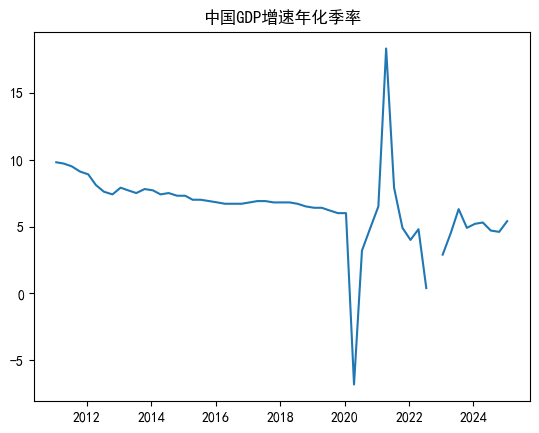

In [5]:
plt.plot(chinaGDPDf['日期'], chinaGDPDf['今值'])
plt.title('中国GDP增速年化季率')

In [6]:
usaGDPDf = ak.macro_usa_gdp_monthly()
usaGDPDf.tail()

,商品,日期,今值,预测值,前值
199,美国国内生产总值(GDP),2024-11-27,2.8,2.8,3.0
200,美国国内生产总值(GDP),2024-12-19,3.1,2.8,3.0
201,美国国内生产总值(GDP),2025-01-30,2.3,2.7,3.1
202,美国国内生产总值(GDP),2025-02-27,2.3,2.3,3.1
203,美国国内生产总值(GDP),2025-03-27,NaN,NaN,2.3


In [7]:
euGDPDf = ak.macro_euro_gdp_yoy()
euGDPDf.tail()

,商品,日期,今值,预测值,前值
478,欧元区季度GDP年率,2025-01-17,0.4,0.4,-0.3
479,欧元区季度GDP年率,2025-02-03,-0.3,NaN,0.4
480,欧元区季度GDP年率,2025-02-24,-0.3,-0.3,0.4
481,欧元区季度GDP年率,2025-03-03,0.5,NaN,-0.3
482,欧元区季度GDP年率,2025-03-19,NaN,0.5,-0.3


## 1.3 与海外主要经济体对比，看走势是否具有一致性，增速谁高谁低

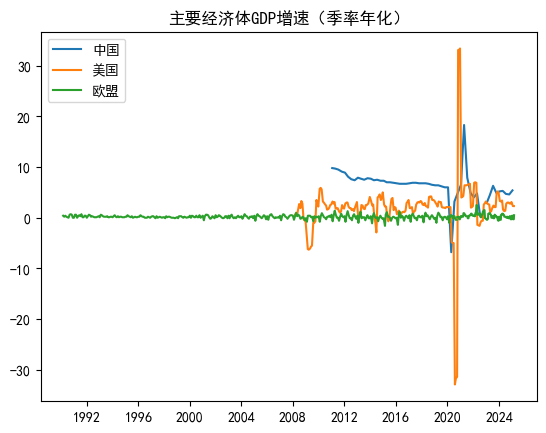

In [8]:
plt.title('主要经济体GDP增速（季率年化）')
plt.plot(chinaGDPDf['日期'], chinaGDPDf['今值'], label="中国")
plt.plot(usaGDPDf['日期'], usaGDPDf['今值'], label="美国")
plt.plot(euGDPDf['日期'], euGDPDf['今值'], label="欧盟")

plt.legend()

# 2. 对GDP进行结构分析

## 2.1 生产法

### 2.1.1 三大产业的GDP占比

从短期看，三大产业的结构不会发生大变动，只有从长期看才会呈现明显的变动趋势

In [9]:
gdpDf = ak.macro_china_nbs_nation(kind='年度数据', path='国民经济核算>三次产业构成', period="last20")
gdpDf = gdpDf.transpose()
gdpDf.head()
gdpDf.columns

Index(['三次产业构成-国内生产总值(%)', '三次产业构成-第一产业增加值(%)', '三次产业构成-第二产业增加值(%)',
       '三次产业构成-第三产业增加值(%)'],
      dtype='object')

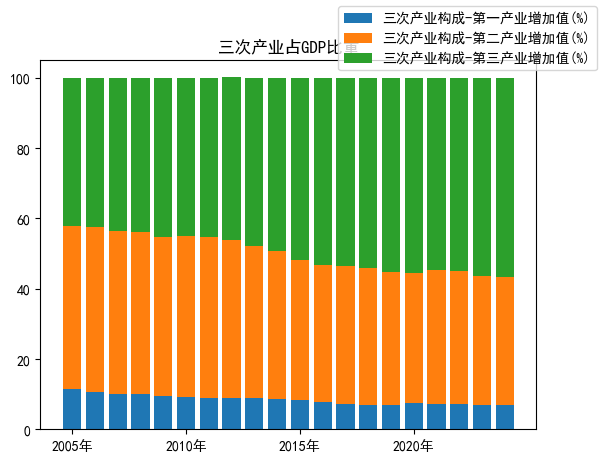

In [10]:
import pandas as pd
import numpy as np


def drawStackedBar(df, title):
    fig = plt.figure()
    ax = fig.gca()
    ax.set_xticks(range(0, df.shape[0], round(df.shape[0] / 4)))
    positiveOffset = np.zeros(df.shape[0])
    negativeOffset = np.zeros(df.shape[0])
    for column in df.columns:
        bottom = [
            v if df[column][i] > 0 else negativeOffset[i]
            for i, v in enumerate(positiveOffset.copy())
        ]
        ax.bar(
            df.index,
            df[column],
            label=column,
            bottom=bottom,
        )
        positiveOffset += df[column].apply(lambda v: v if v > 0 else 0)
        negativeOffset += df[column].apply(lambda v: v if v < 0 else 0)
    fig.legend()
    plt.title(title)


drawStackedBar(
    gdpDf[
        [
            "三次产业构成-第一产业增加值(%)",
            "三次产业构成-第二产业增加值(%)",
            "三次产业构成-第三产业增加值(%)",
        ]
    ].loc[::-1],
    "三次产业占GDP比重"
)

### 2.1.2 三大产业增加值在短期的变动幅度

- 各产业的季调GDP环比数据（优先，但没有数据）
- 各产业的不变价同比数据（替代）

In [11]:
# 不变价
gdpRateDf = ak.macro_china_nbs_nation(kind='季度数据', path='国民经济核算>国内生产总值指数', period="1992-")
gdpRateDf = gdpRateDf.transpose()
gdpRateDf.head()

,国内生产总值指数(上年同期=100)_当季值,国内生产总值指数(上年同期=100)_累计值,第一产业增加值指数(上年同期=100)_当季值,第一产业增加值指数(上年同期=100)_累计值,第二产业增加值指数(上年同期=100)_当季值,第二产业增加值指数(上年同期=100)_累计值,第三产业增加值指数(上年同期=100)_当季值,第三产业增加值指数(上年同期=100)_累计值,农林牧渔业增加值指数(上年同期=100)_当季值,农林牧渔业增加值指数(上年同期=100)_累计值,...,金融业增加值指数(上年同期=100)_当季值,金融业增加值指数(上年同期=100)_累计值,房地产业增加值指数(上年同期=100)_当季值,房地产业增加值指数(上年同期=100)_累计值,信息传输、软件和信息技术服务业增加值指数(上年同期=100)_当季值,信息传输、软件和信息技术服务业增加值指数(上年同期=100)_累计值,租赁和商务服务业增加值指数(上年同期=100)_当季值,租赁和商务服务业增加值指数(上年同期=100)_累计值,其他行业增加值指数(上年同期=100)_当季值,其他行业增加值指数(上年同期=100)_累计值
2024年第四季度,105.4,105.0,103.7,103.5,105.2,105.3,105.8,105.0,103.9,103.7,...,106.5,105.6,102.0,98.2,109.6,110.9,111.0,110.4,103.8,103.4
2024年第三季度,104.6,104.8,103.2,103.4,104.6,105.4,104.8,104.7,103.5,103.6,...,106.2,105.2,98.8,96.9,110.0,111.4,110.8,110.1,103.0,103.3
2024年第二季度,104.7,105.0,103.6,103.5,105.6,105.8,104.2,104.6,103.8,103.7,...,104.3,104.8,96.2,96.0,110.2,112.0,108.7,109.8,103.1,103.5
2024年第一季度,105.3,105.3,103.3,103.3,106.0,106.0,105.0,105.0,103.5,103.5,...,105.2,105.2,95.7,95.7,113.7,113.7,110.8,110.8,103.8,103.8
2023年第四季度,105.3,105.4,104.2,104.1,105.1,104.4,105.7,106.3,104.3,104.2,...,104.4,105.2,97.8,99.3,111.6,112.4,111.0,111.7,103.6,105.0


In [12]:
gdpRateDf.shape

(132, 32)

Text(0.5, 1.0, '三次产业不变价同比增速')

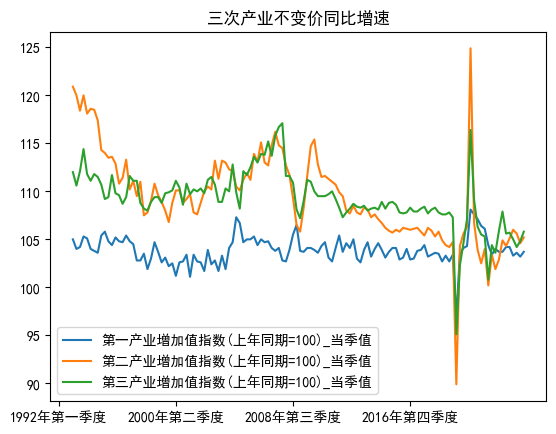

In [13]:
gdpRateDf[
    [
        "第一产业增加值指数(上年同期=100)_当季值",
        "第二产业增加值指数(上年同期=100)_当季值",
        "第三产业增加值指数(上年同期=100)_当季值",
    ]
].loc[::-1].plot(xticks=range(0, gdpRateDf.shape[0], round(gdpRateDf.shape[0] / 4)))
plt.title('三次产业不变价同比增速')

### 2.1.3 三大产业对GDP增速的影响程度

各产业对GDP增长的拉动点数 = 各产业贡献率 * GDP同比

In [14]:
gdpRateByIndustryDf = ak.macro_china_nbs_nation(kind='年度数据', path='国民经济核算 > 三次产业对国内生产总值增长的拉动', period="2000-")
gdpRateByIndustryDf = gdpRateByIndustryDf.transpose()
gdpRateByIndustryDf = gdpRateByIndustryDf.loc[::-1]
gdpRateByIndustryDf.head()

,国内生产总值增长(百分点),第一产业对国内生产总值增长的拉动(百分点),第二产业对国内生产总值增长的拉动(百分点),第三产业对国内生产总值增长的拉动(百分点)
2000年,8.6,0.3,5.0,3.2
2001年,8.3,0.4,3.8,4.1
2002年,9.2,0.4,4.5,4.4
2003年,10.1,0.3,5.8,4.1
2004年,10.1,0.7,5.2,4.2


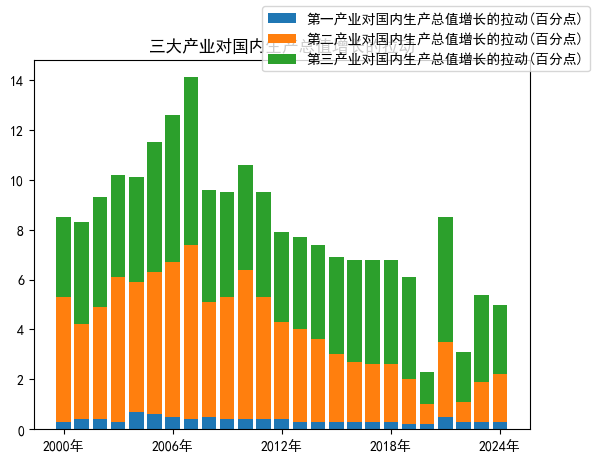

In [15]:
cols = [
    "第一产业对国内生产总值增长的拉动(百分点)",
    "第二产业对国内生产总值增长的拉动(百分点)",
    "第三产业对国内生产总值增长的拉动(百分点)",
]
drawStackedBar(gdpRateByIndustryDf[cols], '三大产业对国内生产总值增长的拉动')

In [16]:
contributionRateByIndustryDf = ak.macro_china_nbs_nation(kind='季度数据', path='国民经济核算>三次产业贡献率', period="2000-")
contributionRateByIndustryDf = contributionRateByIndustryDf.transpose()
contributionRateByIndustryDf.head()

,国内生产总值贡献率_当季值(%),国内生产总值贡献率_累计值(%),第一产业贡献率_当季值(%),第一产业贡献率_累计值(%),第二产业贡献率_当季值(%),第二产业贡献率_累计值(%),第三产业贡献率_当季值(%),第三产业贡献率_累计值(%)
2024年第四季度,100.0,100.0,6.8,5.2,35.7,38.6,57.5,56.2
2024年第三季度,100.0,100.0,6.0,4.5,35.9,39.9,58.1,55.6
2024年第二季度,100.0,100.0,4.9,3.7,44.1,41.9,51.0,54.4
2024年第一季度,100.0,100.0,2.6,2.6,39.8,39.8,57.6,57.6
2023年第四季度,100.0,100.0,7.9,5.6,35.2,29.5,56.9,64.9


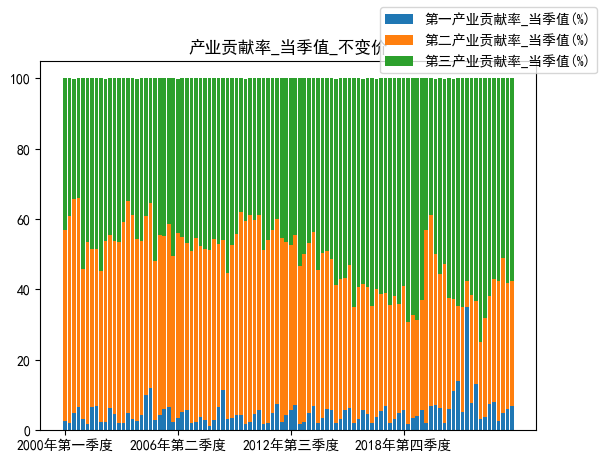

In [17]:
cols = [
    "第一产业贡献率_当季值(%)",
    "第二产业贡献率_当季值(%)",
    "第三产业贡献率_当季值(%)",
]
drawStackedBar(contributionRateByIndustryDf[cols].loc[::-1], title="产业贡献率_当季值_不变价")

### 2.1.4 第一产业

因为第一产业的GDP增长贡献率很低，平均值在5%左右，并且不变价GDP同比波动不大，所以我们对GDP的分析，往往不涉及第一产业。

In [18]:
contributionRateByIndustryDf['第一产业贡献率_当季值(%)'].mean()

np.float64(4.973)

<Axes: >

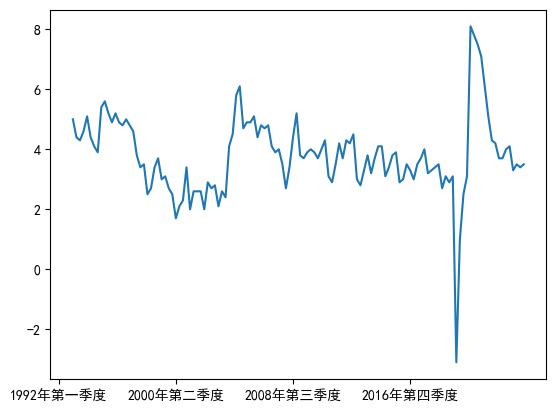

In [19]:
gdpRateDf["第一产业增加值指数(上年同期=100)_累计值"].loc[::-1].apply(
    lambda v: v - 100
).plot(
    xticks=range(0, gdpRateDf.shape[0], round(gdpRateDf.shape[0] / 4)),
)

特殊情况:

2020年一季度，新冠疫情引起的大面积封闭导致第一产业不变价GDP同比大幅走低

### 2.1.5 第二产业

第二产业中工业占85%，建筑业占15%，所以分析第二产业GDP时一般是讨论工业为主。

分析工业经常用**工业增加值**这个指标代替GDP，因为：
1. 工业增加值是月频数据，有利于跟踪短期变化
2. 工业增加值不仅公布总体增速，还同时公布41个子行业增速，有利于跟踪更行各业的动态

工业增加值与GDP项目下的“工业增加值”的区别：
- 工业增加值只统计规模以上的工业企业，即营收在2000万及以上的工业企业
- 工业GDP包含所有工业企业

In [20]:
industrialAddedValueDf = ak.macro_china_nbs_nation(kind='月度数据', path='工业>工业增加值增长速度', period="1992-")
industrialAddedValueDf = industrialAddedValueDf.transpose()
industrialAddedValueDf.head()

,工业增加值_同比增长(%),工业增加值_累计增长(%)
2025年2月,NaN,NaN
2025年1月,NaN,NaN
2024年12月,6.2,5.8
2024年11月,5.4,5.8
2024年10月,5.3,5.8


In [21]:
# industrialAddedValueDf.index
# pd.to_datetime(industrialAddedValueDf.index, format='%Y年%m月')
industrialAddedValueDf.set_index(
    pd.to_datetime(industrialAddedValueDf.index, format="%Y年%m月"), inplace=True
)

In [22]:
def replaceCNChars(index):
    replacements = {"年第一季度": "Q1", "年第二季度": "Q2", "年第三季度": "Q3", "年第四季度": "Q4"}
    for old, new in replacements.items():
        index = index.str.replace(old, new)
    return index


index = replaceCNChars(gdpRateDf.index)
gdpRateDf.set_index(pd.to_datetime(replaceCNChars(gdpRateDf.index)), inplace=True)
gdpRateDf.head()

/tmp/ipykernel_13182/1272052625.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  gdpRateDf.set_index(pd.to_datetime(replaceCNChars(gdpRateDf.index)), inplace=True)


,国内生产总值指数(上年同期=100)_当季值,国内生产总值指数(上年同期=100)_累计值,第一产业增加值指数(上年同期=100)_当季值,第一产业增加值指数(上年同期=100)_累计值,第二产业增加值指数(上年同期=100)_当季值,第二产业增加值指数(上年同期=100)_累计值,第三产业增加值指数(上年同期=100)_当季值,第三产业增加值指数(上年同期=100)_累计值,农林牧渔业增加值指数(上年同期=100)_当季值,农林牧渔业增加值指数(上年同期=100)_累计值,...,金融业增加值指数(上年同期=100)_当季值,金融业增加值指数(上年同期=100)_累计值,房地产业增加值指数(上年同期=100)_当季值,房地产业增加值指数(上年同期=100)_累计值,信息传输、软件和信息技术服务业增加值指数(上年同期=100)_当季值,信息传输、软件和信息技术服务业增加值指数(上年同期=100)_累计值,租赁和商务服务业增加值指数(上年同期=100)_当季值,租赁和商务服务业增加值指数(上年同期=100)_累计值,其他行业增加值指数(上年同期=100)_当季值,其他行业增加值指数(上年同期=100)_累计值
2024-10-01,105.4,105.0,103.7,103.5,105.2,105.3,105.8,105.0,103.9,103.7,...,106.5,105.6,102.0,98.2,109.6,110.9,111.0,110.4,103.8,103.4
2024-07-01,104.6,104.8,103.2,103.4,104.6,105.4,104.8,104.7,103.5,103.6,...,106.2,105.2,98.8,96.9,110.0,111.4,110.8,110.1,103.0,103.3
2024-04-01,104.7,105.0,103.6,103.5,105.6,105.8,104.2,104.6,103.8,103.7,...,104.3,104.8,96.2,96.0,110.2,112.0,108.7,109.8,103.1,103.5
2024-01-01,105.3,105.3,103.3,103.3,106.0,106.0,105.0,105.0,103.5,103.5,...,105.2,105.2,95.7,95.7,113.7,113.7,110.8,110.8,103.8,103.8
2023-10-01,105.3,105.4,104.2,104.1,105.1,104.4,105.7,106.3,104.3,104.2,...,104.4,105.2,97.8,99.3,111.6,112.4,111.0,111.7,103.6,105.0


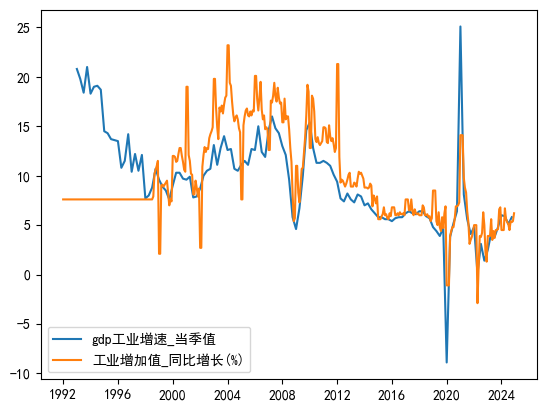

In [23]:
fig = plt.figure()
ax = fig.gca()
ax.plot(
    gdpRateDf.index,
    gdpRateDf["工业增加值指数(上年同期=100)_当季值"] - 100,
    label="gdp工业增速_当季值",
)
ax.plot(
    industrialAddedValueDf.index,
    industrialAddedValueDf["工业增加值_同比增长(%)"].ffill(),
    label="工业增加值_同比增长(%)",
)
plt.legend()

### 2.1.6 第三产业

#### 2.1.6.1 服务业生产指数同比（剔除价格因素）
  
适用性不好：
  - 只覆盖了市场性活动，不包括科教文卫等行业中的非市场性活动
  - 不够准确：参考资料有限，并且部分行业采用了推算预估值
  - 数据披露时间较短（始于2016年12月）

In [24]:
ispDf = ak.macro_china_nbs_nation(kind='月度数据', path='服务业生产指数>服务业生产指数', period="2017-")
ispDf = ispDf.transpose()
ispDf

,服务业生产指数_当月同比增速(%),服务业生产指数_累计同比增速(%)
2025年2月,NaN,NaN
2025年1月,NaN,NaN
2024年12月,6.500000,5.200000
2024年11月,6.100000,5.100000
2024年10月,6.300000,5.000000
...,...,...
2017年5月,8.050503,8.176607
2017年4月,8.062989,8.208133
2017年3月,8.276708,8.256514
2017年2月,8.246417,8.246417


In [25]:
ispDf.set_index(pd.to_datetime(ispDf.index, format="%Y年%m月"), inplace=True)

In [26]:
newIndex = ispDf.index.union(gdpRateDf.index)

ispDf_aligned = ispDf.reindex(newIndex).ffill()
gdpRateDf_aligned = gdpRateDf.reindex(newIndex).ffill()

ispDf_aligned

,服务业生产指数_当月同比增速(%),服务业生产指数_累计同比增速(%)
1992-01-01,NaN,NaN
1992-04-01,NaN,NaN
1992-07-01,NaN,NaN
1992-10-01,NaN,NaN
1993-01-01,NaN,NaN
...,...,...
2024-10-01,6.3,5.0
2024-11-01,6.1,5.1
2024-12-01,6.5,5.2
2025-01-01,6.5,5.2


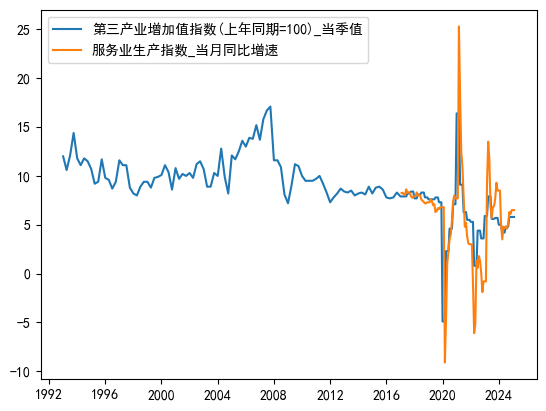

In [27]:
fig = plt.figure()
ax = fig.gca()
ax.plot(
    gdpRateDf_aligned.index,
    gdpRateDf_aligned['第三产业增加值指数(上年同期=100)_当季值'] - 100,
    label="第三产业增加值指数(上年同期=100)_当季值"
)
ax.plot(
    ispDf_aligned.index,
    ispDf_aligned["服务业生产指数_当月同比增速(%)"],
    label="服务业生产指数_当月同比增速"
)

plt.legend()


#### 2.1.6.2 服务业PMI

- 通过调查问卷的形式统计获得
- 因为是环比数据，所以不适合直接与GDP同比进行比较

In [28]:
pmiServiceDf = ak.index_pmi_ser_cx()
pmiServiceDf

,日期,服务业PMI,变化值
0,2014-04-30,51.4,0.0
1,2014-05-31,50.7,-0.7
2,2014-06-30,53.1,2.4
3,2014-07-31,50.0,-3.1
4,2014-08-31,54.1,4.1
...,...,...,...
126,2024-10-31,52.0,1.7
127,2024-11-30,51.5,-0.5
128,2024-12-31,52.2,0.7
129,2025-01-31,51.0,-1.2


<Axes: xlabel='日期'>

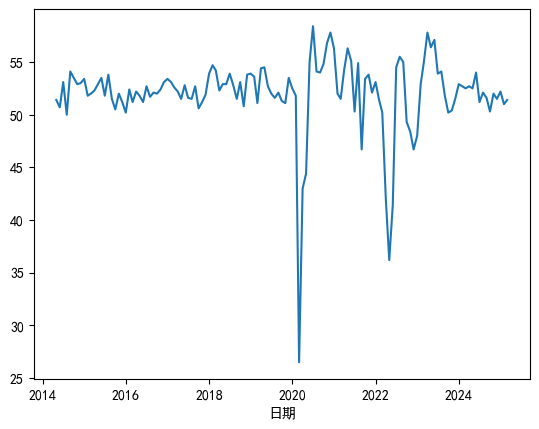

In [29]:
# pmiServiceDf['服务业PMI'].plot(index=pmiServiceDf['日期'])
pmiSerSeries = pmiServiceDf['服务业PMI']
pmiSerSeries.index = pmiServiceDf['日期']
pmiSerSeries.plot()

#### 2.1.6.3 分行业具体分析第三产业

由于服务业生产指数同比和服务业pmi都不是完善的综合性指标，所以需要分行业具体分析第三产业

第三产业包括以下行业：（带星号表示公布了季度增加值数据）

1. 批发和零售业*
2. 交通运输、仓储和邮政业*
3. 住宿和餐饮业*
4. 信息传输、软件和信息技术服务业*
5. 金融业*
6. 房地产业*
7. 租赁和商务服务业*
8. 科学研究和技术服务业
9. 水利、环境和公共设施管理业
10. 居民服务、修理和其他服务业
11. 教育
12. 卫生和社会工作
13. 文化、体育和娱乐业
14. 公共管理、社会保障和社会组织
15. 国际组织

分析方法：

1. 优先分析占比较大，波动性也较大的行业
2. 选择一些指标来拟合行业GDP同比（优先选择统计局在GDP核算过程中使用了的指标）
    - 指标应该不包含价格因素，最好是物量指标
    - 只能通过拟合用指标分析GDP变化的原因，判断趋势和拐点。即只能进行定性分析无法定量。


一些有用的替代指标：

1. 金融业GDP同比 - 股票成交量月度同比
2. 房地产业GDP同比 - 商品房销售面积同比




In [30]:
gdp2023Df = ak.macro_china_nbs_nation(kind='季度数据', path='国民经济核算>国内生产总值(现价)', period="2023")
gdp2023Df = gdp2023Df.transpose()
gdp2023Df

,国内生产总值_当季值(亿元),国内生产总值_累计值(亿元),第一产业增加值_当季值(亿元),第一产业增加值_累计值(亿元),第二产业增加值_当季值(亿元),第二产业增加值_累计值(亿元),第三产业增加值_当季值(亿元),第三产业增加值_累计值(亿元),农林牧渔业增加值_当季值(亿元),农林牧渔业增加值_累计值(亿元),...,金融业增加值_当季值(亿元),金融业增加值_累计值(亿元),房地产业增加值_当季值(亿元),房地产业增加值_累计值(亿元),信息传输、软件和信息技术服务业增加值_当季值(亿元),信息传输、软件和信息技术服务业增加值_累计值(亿元),租赁和商务服务业增加值_当季值(亿元),租赁和商务服务业增加值_累计值(亿元),其他行业增加值_当季值(亿元),其他行业增加值_累计值(亿元)
2023年第四季度,357224.8,1294271.7,33213.5,89169.1,131746.0,475936.1,192265.3,729166.5,34964.6,93967.0,...,22661.4,93926.9,21653.9,87981.5,14410.8,57498.4,15223.0,50438.9,58187.7,221303.2
2023年第三季度,328440.7,937047.0,25759.7,55955.6,119681.7,344190.1,182999.2,536901.2,27037.3,59002.4,...,23693.8,71265.5,20855.2,66327.6,12966.8,43087.5,12818.5,35216.0,55810.2,163115.5
2023年第二季度,316237.5,608606.3,18695.5,30195.9,119928.9,224508.4,177613.2,353902.0,19747.4,31965.1,...,23695.1,47571.7,22561.5,45472.3,15419.9,30120.7,11119.5,22397.5,52177.6,107305.4
2023年第一季度,292368.8,292368.8,11500.4,11500.4,104579.5,104579.5,176288.8,176288.8,12217.8,12217.8,...,23876.6,23876.6,22910.9,22910.9,14700.8,14700.8,11278.0,11278.0,55127.7,55127.7


/tmp/ipykernel_13182/2871052653.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_1.set_xticklabels(cols, rotation=45, ha='right')


[Text(0, 0, '批发和零售业'),
 Text(1, 0, '交通运输、仓储和邮政业'),
 Text(2, 0, '住宿和餐饮业'),
 Text(3, 0, '金融业'),
 Text(4, 0, '房地产业'),
 Text(5, 0, '信息传输、软件和信息技术服务业'),
 Text(6, 0, '租赁和商务服务业'),
 Text(7, 0, '其他行业')]

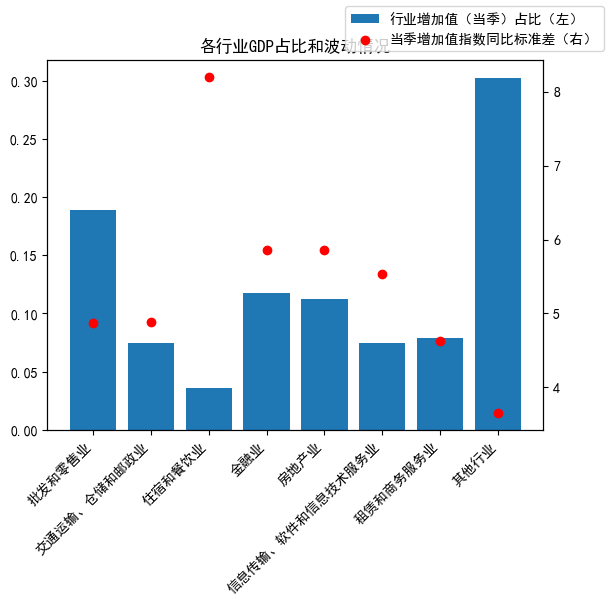

In [31]:
cols = [
    "批发和零售业",
    "交通运输、仓储和邮政业",
    "住宿和餐饮业",
    "金融业",
    "房地产业",
    "信息传输、软件和信息技术服务业",
    "租赁和商务服务业",
    "其他行业",
]

cols1 = [v + "增加值_当季值(亿元)" for v in cols]
cols2 = [v + "增加值指数(上年同期=100)_当季值" for v in cols]

fig = plt.figure()

ax_1 = fig.gca()
ax_1.bar(
    cols, gdp2023Df[cols1].iloc[0] / gdp2023Df["第三产业增加值_当季值(亿元)"].iloc[0]
)

ax_2 = ax_1.twinx()
ax_2.scatter(cols, gdpRateDf[cols2].std(), c="red")

fig.legend(["行业增加值（当季）占比（左）", "当季增加值指数同比标准差（右）"])
plt.title('各行业GDP占比和波动情况')

ax_1.set_xticklabels(cols, rotation=45, ha='right')


住宿和餐饮业波动高，但占比低，没有分析意义。
金融业和房地产业波动高，占比高，分析意义较大。

In [32]:
fdcMonthlyDf = ak.macro_china_nbs_nation(kind="月度数据", path="房地产>商品房销售面积", period="2000-")
fdcMonthlyDf = fdcMonthlyDf.transpose()
fdcMonthlyDf.head()

,商品房销售面积_累计值(万平方米),商品房销售面积_累计增长(%),商品房现房销售面积_累计值(万平方米),商品房现房销售面积_累计增长(%),商品房期房销售面积_累计值(万平方米),商品房期房销售面积_累计增长(%)
2025年2月,NaN,NaN,NaN,NaN,NaN,NaN
2025年1月,NaN,NaN,NaN,NaN,NaN,NaN
2024年12月,97385.0119,-12.9,30031.9223,19.1,67353.0896,-22.2
2024年11月,86117.9532,-14.3,26147.2032,19.4,59970.7500,-23.7
2024年10月,77930.1583,-15.8,23669.6424,18.8,54260.5159,-25.3


In [33]:
fdcMonthlySeries = fdcMonthlyDf.loc[::-1]["商品房销售面积_累计增长(%)"]
fdcMonthlySeries.index = pd.to_datetime(fdcMonthlySeries.index, format="%Y年%m月")
fdcMonthlySeries

2000-01-01     NaN
2000-02-01    53.3
2000-03-01    35.7
2000-04-01    35.8
2000-05-01    37.8
              ... 
2024-10-01   -15.8
2024-11-01   -14.3
2024-12-01   -12.9
2025-01-01     NaN
2025-02-01     NaN
Name: 商品房销售面积_累计增长(%), Length: 302, dtype: float64

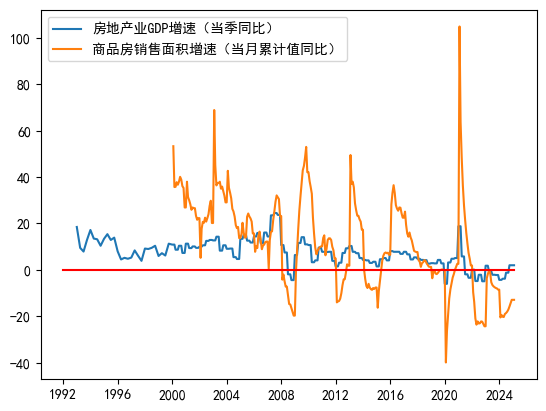

In [34]:
gdpFdcSeries = gdpRateDf["房地产业增加值指数(上年同期=100)_当季值"] - 100
gdpFdcSeries = gdpFdcSeries.sort_index(ascending=True)

newIndex = fdcMonthlySeries.index.union(gdpFdcSeries.index)

gdpFdcSeries = gdpFdcSeries.reindex(newIndex).ffill()
fdcMonthlySeries = fdcMonthlySeries.reindex(newIndex).ffill()

fig = plt.figure()
ax = fig.gca()
ax.plot(newIndex, gdpFdcSeries, label="房地产业GDP增速（当季同比）")
ax.plot(newIndex, fdcMonthlySeries, label="商品房销售面积增速（当月累计值同比）")
ax.plot(newIndex, [0]*len(newIndex), c="red")
plt.legend()

## 2.2 支出法

支出法是分析GDP的主要视角

### 2.2.1 三大需求

三大需求是指消费、投资、净出口

In [35]:
demandDf = ak.macro_china_nbs_nation(kind="年度数据", path="国民经济核算>三大需求对国内生产总值增长的贡献率和拉动", period="2000-")
demandDf = demandDf.transpose()
demandDf.head()

,最终消费支出对国内生产总值增长贡献率(%),最终消费支出对国内生产总值增长拉动(百分点),资本形成总额对国内生产总值增长贡献率(%),资本形成总额对国内生产总值增长拉动(百分点),货物和服务净出口对国内生产总值增长贡献率(%),货物和服务净出口对国内生产总值增长拉动(百分点)
2024年,NaN,2.2,NaN,1.3,NaN,1.5
2023年,85.6,4.6,25.8,1.4,-11.4,-0.6
2022年,49.3,1.5,37.1,1.2,13.6,0.4
2021年,60.1,5.2,19.7,1.7,20.2,1.7
2020年,-4.3,-0.1,75.1,1.8,29.1,0.7


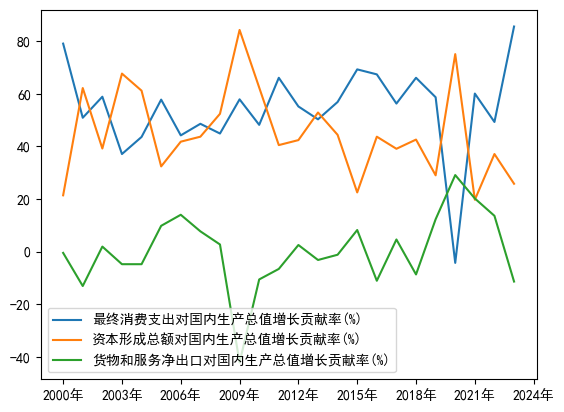

In [36]:
fig = plt.figure()
ax = fig.gca()
ax.set_xticks(range(0, demandDf.shape[0], round(demandDf.shape[0] / 8)))

for col in [
    "最终消费支出对国内生产总值增长贡献率(%)",
    "资本形成总额对国内生产总值增长贡献率(%)",
    "货物和服务净出口对国内生产总值增长贡献率(%)",
]:
    s = demandDf[col]
    s = s.sort_index(ascending=True)
    ax.plot(s.index, s, label=col)

plt.legend()


对经济增长的影响力：消费>投资>净出口

### 2.2.2 消费

可用指标：

1. GDP-最终消费支出（年频）
2. 居民消费支出（季度）
3. 社会消费品零售总额（月度）

居民消费支出这个指标不包含政府消费支出，而且仅披露人均支出，所以不常用

市场常用指标是：社会消费品零售总额

#### 2.2.2.1 社会消费品零售总额与GDP最终消费支出的差异

1. 社会消费品零售总额只包含商品零售、餐饮服务，其他服务性消费支出（如教育医疗支出等）均未被包括在内。而GDP最终消费支出涵盖上述支出
2. GDP最终消费支出还包括“虚拟消费支出”，比如：居民的自有住房服务价值、一些自产自销的商品或服务（比如农产品）、隐含在利息中的金融中介服务等。这些社会消费品零售总额都不包括。
3. 社会消费品零售总额中，有一些消费行为在GDP中记为投资。比如：居民建房时买的建筑材料。

In [37]:
consumeDf = ak.macro_china_nbs_nation(kind="季度数据", path="人民生活>全国居民人均支出情况", period="2000-")
consumeDf = consumeDf.transpose()
consumeDf.head()

,居民人均消费支出_累计值(元),居民人均消费支出_累计增长(%),居民人均食品烟酒支出_累计值(元),居民人均食品烟酒支出_累计增长(%),居民人均衣着支出_累计值(元),居民人均衣着支出_累计增长(%),居民人均居住支出_累计值(元),居民人均居住支出_累计增长(%),居民人均生活用品及服务支出_累计值(元),居民人均生活用品及服务支出_累计增长(%),居民人均交通通信支出_累计值(元),居民人均交通通信支出_累计增长(%),居民人均教育文化娱乐支出_累计值(元),居民人均教育文化娱乐支出_累计增长(%),居民人均医疗保健支出_累计值(元),居民人均医疗保健支出_累计增长(%),居民人均其他用品及服务支出_累计值(元),居民人均其他用品及服务支出_累计增长(%)
2024年第四季度,28227.0505,5.08982,8411.0064,5.361946,1520.7784,2.834654,6263.0,2.755489,1547.3377,1.37994,3975.5278,8.857434,3188.7617,9.808555,2547.0265,3.555145,772.5318,10.842028
2024年第三季度,20631.0000,5.30000,6206.0000,7.100000,1109.0000,5.100000,4560.0,1.000000,1117.0000,-0.30000,2865.0000,10.000000,2295.0000,10.100000,1900.0000,3.500000,579.0000,10.900000
2024年第二季度,13601.0000,6.70000,4214.0000,7.800000,826.0000,8.100000,3004.0,1.900000,738.0000,2.20000,1819.0000,11.600000,1340.0000,11.200000,1271.0000,4.200000,389.0000,13.800000
2024年第一季度,7299.0000,8.30000,2354.0000,10.600000,492.0000,12.400000,1562.0,0.100000,380.0000,2.90000,946.0000,14.800000,722.0000,13.400000,629.0000,3.900000,214.0000,21.700000
2023年第四季度,26796.0000,9.00000,7983.0000,6.700000,1479.0000,8.400000,6095.0,3.600000,1526.0000,6.60000,3652.0000,14.300000,2904.0000,17.600000,2460.0000,16.000000,697.0000,17.100000


In [38]:
# 支出法GDP
zcfGDPDf = ak.macro_china_nbs_nation(kind="年度数据", path="国民经济核算>支出法国内生产总值", period="2000-")
zcfGDPDf = zcfGDPDf.transpose()
zcfGDPDf.head()


,支出法生产总值(亿元),最终消费(亿元),居民消费(亿元),城镇居民消费(亿元),农村居民消费(亿元),政府消费(亿元),资本形成总额(亿元),固定资本形成总额(亿元),存货变动(亿元),货物和服务净出口(亿元),最终消费率(%),资本形成率(%)
2024年,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023年,1294271.7,734594.8,512120.6,405863.3,106257.3,222474.2,532330.2,523590.3,8740.0,27346.7,56.8,41.1
2022年,1233412.8,671803.9,466181.2,367595.8,98585.4,205622.6,522678.5,508826.5,13852.0,38930.5,54.5,42.4
2021年,1173109.7,642376.7,450442.5,356069.8,94372.7,191934.2,501014.2,485400.7,15613.5,29718.8,54.8,42.7
2020年,1042244.9,577169.4,394993.4,311053.3,83940.1,182176.0,440567.7,433086.0,7481.7,24507.9,55.4,42.3


In [39]:
# 最终消费GDP
zzxfGDPSeries = zcfGDPDf['最终消费(亿元)'].sort_index(ascending=True)
zzxfGDPSeries = zzxfGDPSeries.pct_change(periods=1)
zzxfGDPSeries

2000年         NaN
2001年    0.079283
2002年    0.083057
2003年    0.076009
2004年    0.122796
2005年    0.141146
2006年    0.134403
2007年    0.195325
2008年    0.155495
2009年    0.099675
2010年    0.156136
2011年    0.213931
2012年    0.123094
2013年    0.112375
2014年    0.102810
2015年    0.100717
2016年    0.108355
2017年    0.111100
2018年    0.111033
2019年    0.088567
2020年    0.015521
2021年    0.112978
2022年    0.045810
2023年    0.093466
2024年    0.000000
Name: 最终消费(亿元), dtype: float64

In [40]:
# 社会消费品零售总额
shxfplszeDf = ak.macro_china_nbs_nation(
    kind="月度数据", path="国内贸易>社会消费品零售总额", period="2000-"
)
shxfplszeDf = shxfplszeDf.transpose()
shxfplszeDf.head()

,社会消费品零售总额_当期值(亿元),社会消费品零售总额_累计值(亿元),社会消费品零售总额_同比增长(%),社会消费品零售总额_累计增长(%),限上单位消费品零售额_当期值(亿元),限上单位消费品零售额_累计值(亿元),限上单位消费品零售额_同比增长(%),限上单位消费品零售额_累计增长(%)
2025年2月,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025年1月,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024年12月,45171.5,487894.8,3.7,3.5,19453.4,192552.5,4.0,2.7
2024年11月,43763.0,442723.3,3.0,3.5,17748.1,173397.6,1.3,2.6
2024年10月,45396.4,398960.3,4.8,3.5,16985.5,155131.4,6.2,2.7


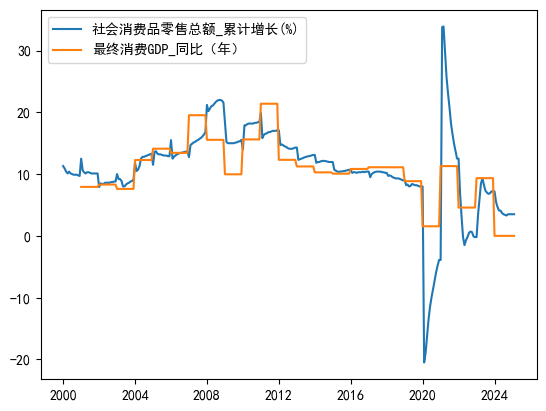

In [41]:
# pd.to_datetime(shxfplszeDf.index, format="%Y年%m月")
# pd.to_datetime(zzxfGDPSeries.index, format="%Y年")

shxfplszeSeries = shxfplszeDf["社会消费品零售总额_累计增长(%)"].sort_index(
    ascending=True
)

shxfplszeSeries.index = pd.to_datetime(shxfplszeSeries.index, format="%Y年%m月")
zzxfGDPSeries.index = pd.to_datetime(zzxfGDPSeries.index, format="%Y年")
newIndex = zzxfGDPSeries.index.union(shxfplszeSeries.index)

zzxfGDPSeries = zzxfGDPSeries.reindex(newIndex).ffill()
shxfplszeSeries= shxfplszeSeries.reindex(newIndex).ffill()

fig = plt.figure()
ax = fig.gca()
ax.plot(shxfplszeSeries.index, shxfplszeSeries, label="社会消费品零售总额_累计增长(%)")
ax.plot(zzxfGDPSeries.index, zzxfGDPSeries * 100, label="最终消费GDP_同比（年）")
plt.legend()

### 2.2.3 投资

#### GDP-资产形成总额由两部分组成

1. 固定资本形成总额（占比95%以上）
2. 存货增加

#### 固定资产投资完成额

固定资产投资完成额反映全社会建造和购买固定资产的工作量和相关费用

固定资产投资完成额与固定资本形成总额的区别：

1. 主要区别：固定资产投资完成额只统计500万及以上的非农户项目（房地产企业开发房地产项目），而固定资本形成总额没有规模限制。
2. 固定资产投资完成额包括土地购置费、旧建筑物购置费和旧设备购置费，但固定资本形成总额不包含。
3. 固定资本形成总额包含商品房销售增值，以及培育性生物资源、知识产权产品等无形固定资产的增加。固定资产投资完成额不包括。

In [42]:
gdzbRateSeries = zcfGDPDf['固定资本形成总额(亿元)'].sort_index(ascending=True).pct_change(1)
gdzbRateSeries.index = pd.to_datetime(gdzbRateSeries.index, format="%Y年")
gdzbRateSeries

2000-01-01         NaN
2001-01-01    0.134645
2002-01-01    0.149663
2003-01-01    0.230325
2004-01-01    0.217462
2005-01-01    0.154008
2006-01-01    0.149689
2007-01-01    0.204634
2008-01-01    0.218413
2009-01-01    0.222906
2010-01-01    0.185597
2011-01-01    0.182228
2012-01-01    0.113598
2013-01-01    0.107627
2014-01-01    0.069209
2015-01-01    0.027703
2016-01-01    0.069573
2017-01-01    0.122387
2018-01-01    0.130242
2019-01-01    0.071341
2020-01-01    0.019063
2021-01-01    0.120795
2022-01-01    0.048261
2023-01-01    0.029015
2024-01-01    0.000000
Name: 固定资本形成总额(亿元), dtype: float64

In [43]:
gdzcRateDf = ak.macro_china_nbs_nation(kind="月度数据", path="固定资产投资(不含农户)>固定资产投资概况", period="2000-")
gdzcRateDf = gdzcRateDf.transpose()
gdzcRateDf.head()

,固定资产投资额_累计增长(%),民间固定资产投资_累计增长(%),第一产业固定资产投资额_累计增长(%),第二产业固定资产投资额_累计增长(%),第三产业固定资产投资额_累计增长(%)
2025年2月,NaN,NaN,NaN,NaN,NaN
2025年1月,NaN,NaN,NaN,NaN,NaN
2024年12月,3.2,-0.1,2.6,12.0,-1.1
2024年11月,3.3,-0.4,2.4,12.0,-1.0
2024年10月,3.4,-0.3,2.5,12.2,-0.9


In [44]:
gdzcRateSeries = gdzcRateDf['固定资产投资额_累计增长(%)'].sort_index(ascending=True)
gdzcRateSeries.index = pd.to_datetime(gdzcRateSeries.index, format="%Y年%m月")
gdzcRateSeries

2000-10-01    12.6
2000-11-01    11.7
2000-12-01     9.7
2000-01-01     NaN
2000-02-01     8.6
              ... 
2024-07-01     3.6
2024-08-01     3.4
2024-09-01     3.4
2025-01-01     NaN
2025-02-01     NaN
Name: 固定资产投资额_累计增长(%), Length: 302, dtype: float64

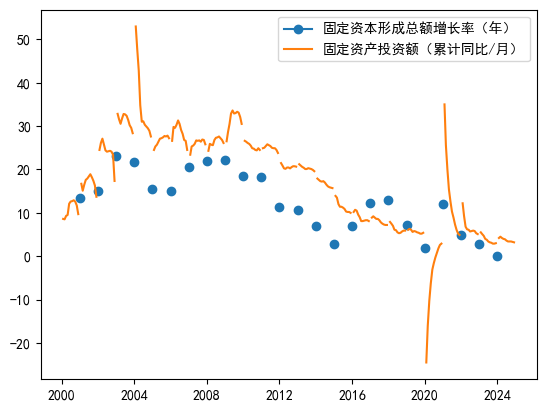

In [45]:
idxs = gdzbRateSeries.index.union(gdzcRateSeries.index).sort_values(ascending=True)

fig = plt.figure()
ax = fig.gca()
ax.plot(
    idxs,
    (gdzbRateSeries * 100).reindex(idxs),
    label="固定资本形成总额增长率（年）",
    marker="o"
)
ax.plot(idxs, gdzcRateSeries.reindex(idxs), label="固定资产投资额（累计同比/月）")
plt.legend()

2017-2018年固定资本形成总额与固定资产投资完成额走势背离，猜测是因为固定资产形成总额将更多的知识产权产品纳入核算范围，特别是纳入研究与开发支出。

### 2.2.4 进出口

海关-进出口贸易差额

外管局-国际货物和服务贸易进出口月度数据

在分析时更关注出口数据，因为它反应海外需求

<Axes: >

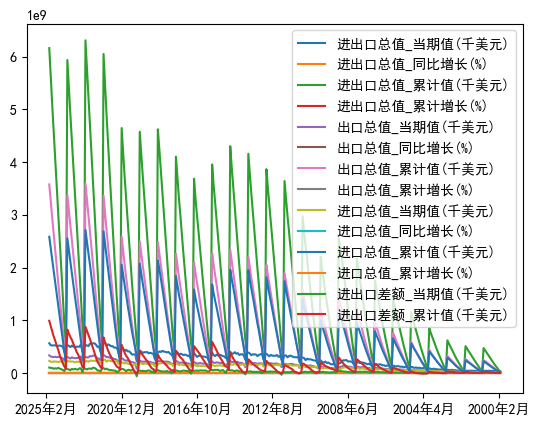

In [46]:
jckDf = ak.macro_china_nbs_nation(kind="月度数据", path="对外经济>进出口总额", period="2000-")
jckDf = jckDf.transpose()
jckDf.plot()